### MODELO REGRESIÓN LOGISTICA

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
# Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings
import zipfile
import os



In [18]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_temporal_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_temporal_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_temporal_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_temporal_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [19]:
X_train.shape

(496369, 19)

In [20]:
X_test.shape

(123726, 19)

In [21]:
y_train.shape

(496369, 1)

In [22]:
y_test.shape

(123726, 1)

Como se cargó estos datos desde archivos .csv, es muy probable que se haya colado una columna llamada Unnamed: 0 (que suele ser el índice antiguo). Antes de entrenar vamos a limpiar las X.

In [23]:
# Eliminar columna de índice sobrante si existe
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)


In [24]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {"X_train": X_train,"X_test": X_test,"y_train": y_train, "y_test": y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f"{nombre}: {total_nulos} nulos encontrados.")
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f"{nombre}: No está cargado (es None)."

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


In [25]:
model = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, 
                                               intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto',
                                            verbose=0 , warm_start = False , n_jobs = None , l1_ratio = None )


In [26]:
model.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'auto'


In [27]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(123726,))

In [28]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.5198018201509788

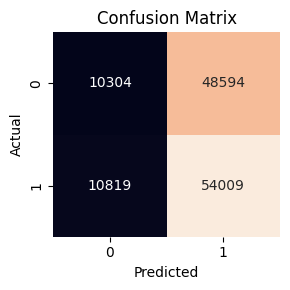

In [29]:
bank_cm = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [30]:
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='macro'):.4f}")

Precision: 0.5071
Recall:    0.5040
F1-Score:  0.4513


Precision: ¿Qué tan confiable es el modelo cuando dice que alguien pertenece a una clase? 
- 50.5%

Recall: ¿Qué tantos casos reales fue capaz de "atrapar" el modelo? 
- 50.2%

#### Hiperparametrización 
Con Random Search porque hay demasiados registros y con Grid Search daba error por falta de RAM.

In [31]:
 # 1. Definir el modelo base
log_reg = LogisticRegression(max_iter=1000)

param_grid = {'C': [0.01, 0.1, 1, 10, 100],'penalty': ['l1', 'l2'],'solver': ['liblinear', 'saga']}

# Definimos el esquema de validación temporal
tscv = TimeSeriesSplit(n_splits=5)

# En el RandomizedSearchCV, cambia cv=3 por cv=tscv
random_search = RandomizedSearchCV(
    estimator=log_reg, 
    param_distributions=param_grid, 
    n_iter=10, 
    cv=tscv,  # <--- CAMBIO CLAVE
    scoring='roc_auc',  # <--- CAMBIO CLAVE (Ahora optimiza para ROC-AUC)
    n_jobs=-1
)

random_search.fit(X_train, y_train)

f"Mejores parámetros:", random_search.best_params_

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


('Mejores parámetros:', {'solver': 'liblinear', 'penalty': 'l1', 'C': 1})

--- REPORTE FINAL DEL MODELO OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.49      0.18      0.26     58898
           1       0.53      0.83      0.64     64828

    accuracy                           0.52    123726
   macro avg       0.51      0.50      0.45    123726
weighted avg       0.51      0.52      0.46    123726



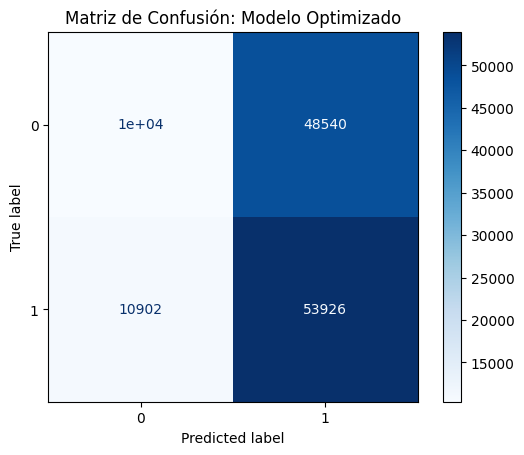

In [35]:
# 1. Obtener el mejor modelo
best_model = random_search.best_estimator_

# 2. Hacer predicciones con los datos de TEST
y_pred = best_model.predict(X_test)

# 3. Reporte de métricas
print("--- REPORTE FINAL DEL MODELO OPTIMIZADO ---")
print(classification_report(y_test, y_pred))

# 4. Matriz de Confusión visual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Matriz de Confusión: Modelo Optimizado")
plt.show()

ROC-AUC Score: 0.5086


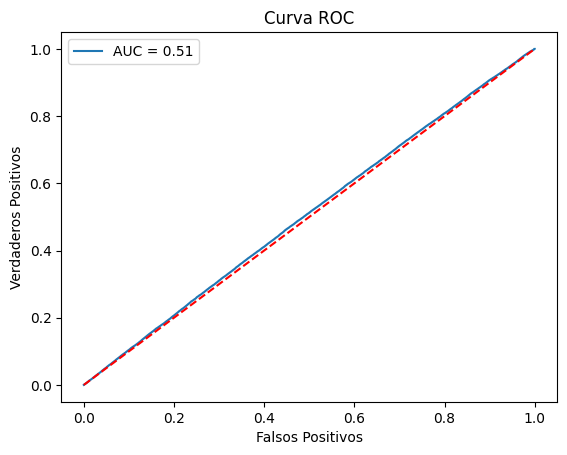

In [36]:
from sklearn.metrics import roc_auc_score, roc_curve

# Obtenemos las probabilidades (necesarias para el AUC)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Calculamos el AUC
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Dibujar la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'r--') # Línea de azar
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Conclusión:
Este modelo no me parece que de un buen resultado de predicción. Ya que es solo el 50%. Es como lanzar una moneda al aire.